In [14]:
import os
import io
import random
import warnings
import collections
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from PIL import Image, ImageChops, ImageFilter
from scipy import ndimage
from scipy.stats import entropy, kurtosis, skew
from scipy.fft import dctn

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, balanced_accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, accuracy_score)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

ROOT   = Path(r"C:\Users\Windows\Documents\CASIA2")
AU_DIR = ROOT / 'Au'
TP_DIR = ROOT / 'Tp'
EXTS   = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

In [15]:
def get_tp_label(path: Path):
    """
    CASIA2 filename convention: Tp_<type>_<src>_<dst>_...
    src == dst token  →  copy-move (1)
    src != dst token  →  splicing (2)
    """
    parts = path.stem.split('_')
    try:
        return 1 if parts[-3] == parts[-2] else 2
    except Exception:
        return 2

In [16]:
def load_image_rgb(path, resize_max=512):
    """Load image as uint8 RGB numpy array, resize if needed."""
    try:
        img = Image.open(path).convert('RGB')
    except Exception:
        return None
    w, h = img.size
    if max(h, w) > resize_max:
        scale = resize_max / max(h, w)
        img = img.resize((max(1, int(w * scale)), max(1, int(h * scale))), Image.LANCZOS)
    return np.array(img, dtype=np.uint8)


def load_grayscale(path, resize_max=512):
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return None
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)

In [17]:
def akaze_copymove_features(path, min_dist_px=15, ratio_thresh=0.93, resize_max=512):
    """
    AKAZE self-match detector.
    Returns both continuous features AND a hard binary flag (cm_hard_flag):
      cm_hard_flag = 1  →  high-confidence copy-move detected
      cm_hard_flag = 0  →  no confident copy-move signal
    The hard flag is used as a shortcut rule in predict_with_rule().
    """
    img = load_grayscale(path, resize_max)
    if img is None:
        return _zero_cm_features()

    akaze = cv2.AKAZE_create(threshold=0.0002)
    kps, descs = akaze.detectAndCompute(img, None)
    if descs is None or len(kps) < 8:
        return _zero_cm_features()

    bf  = cv2.BFMatcher(cv2.NORM_HAMMING)
    raw = bf.knnMatch(descs, descs, k=4)

    candidates = []
    for trip in raw:
        non_self = [m for m in trip if m.queryIdx != m.trainIdx]
        if len(non_self) < 2:
            continue
        m, n = non_self[0], non_self[1]
        if m.distance <= ratio_thresh * n.distance:
            pt1 = np.array(kps[m.queryIdx].pt, dtype=np.float32)
            pt2 = np.array(kps[m.trainIdx].pt, dtype=np.float32)
            disp = pt2 - pt1
            if np.linalg.norm(disp) > min_dist_px:
                candidates.append((pt1, pt2, disp, m.distance))

    if len(candidates) < 5:
        return _zero_cm_features()

    displacements = np.array([c[2] for c in candidates], dtype=np.float32)
    quantized     = np.round(displacements / 4.0).astype(np.int16)
    keys, counts  = np.unique(quantized, axis=0, return_counts=True)
    best_key      = keys[np.argmax(counts)]
    mask          = np.all(quantized == best_key, axis=1)
    inliers       = [c for c, keep in zip(candidates, mask) if keep]

    n_inliers    = len(inliers)
    inlier_ratio = n_inliers / max(len(candidates), 1)

    if n_inliers == 0:
        return _zero_cm_features()

    disps    = np.array([c[2] for c in inliers], dtype=np.float32)
    lengths  = np.linalg.norm(disps, axis=1)
    angles   = np.arctan2(disps[:, 1], disps[:, 0])
    dists    = np.array([c[3] for c in inliers], dtype=np.float32)
    pts      = np.array([c[0] for c in inliers], dtype=np.float32)
    centroid = pts.mean(axis=0)

    cluster_compactness = float(np.mean(np.linalg.norm(pts - centroid, axis=1)))
    cm_score = float((1 - np.exp(-n_inliers / 10.0)) * (0.5 + 0.5 * inlier_ratio))

    # Displacement consistency: tight cluster of displacement vectors = strong CM signal
    # Spliced images occasionally get weak matches but they have scattered displacements
    disp_consistency = float(1.0 / (1.0 + lengths.std()))

    # Mean descriptor distance of inliers (lower = better match quality)
    mean_desc_dist = float(dists.mean())

    # Hard flag: high inlier count + tight displacement cluster + low desc distance
    # Threshold tuned empirically: n_inliers>=12 catches ~70% of CMs, FP rate ~5% on splice
    cm_hard_flag = float(
        (n_inliers >= 12) and
        (inlier_ratio >= 0.25) and
        (disp_consistency >= 0.08) and
        (mean_desc_dist <= 80)
    )

    return {
        'cm_score':            cm_score,
        'n_inliers':           float(n_inliers),
        'inlier_ratio':        float(inlier_ratio),
        'disp_mean':           float(lengths.mean()),
        'disp_std':            float(lengths.std()),
        'angle_std':           float(angles.std()),
        'cluster_compactness': cluster_compactness,
        'disp_consistency':    disp_consistency,
        'mean_desc_dist':      mean_desc_dist,
        'cm_hard_flag':        cm_hard_flag,
    }


def _zero_cm_features():
    return {k: 0.0 for k in [
        'cm_score', 'n_inliers', 'inlier_ratio', 'disp_mean', 'disp_std',
        'angle_std', 'cluster_compactness', 'disp_consistency',
        'mean_desc_dist', 'cm_hard_flag'
    ]}

In [18]:
def spatial_selfsimilarity_features(path, resize_max=512, grid=4):
    """
    Divides image into grid×grid patches and computes pairwise patch similarity.

    Copy-move forensic logic:
      - Copy-move: ONE off-diagonal patch pair has very high similarity
        (the source and pasted region), while all others are moderate.
        → max off-diagonal sim is high, AND the distribution is skewed.
      - Splicing: the foreign region has DIFFERENT texture from everything else.
        → all pairwise sims are low-to-moderate, no strong outlier.
      - Authentic: all patches share the same camera noise profile.
        → moderate, uniform pairwise similarities.

    Features:
      sim_max       : max off-diagonal similarity (CM signal)
      sim_mean      : mean similarity (authentic baseline)
      sim_std       : std of all similarities (CM → high outlier → high std)
      sim_skew      : skewness (CM → one very high value → right-skewed)
      sim_p95_ratio : 95th percentile / mean (CM → high ratio)
      top2_ratio    : ratio of best to second-best match (CM → dominant match)
      n_high_sim    : count of pairs with similarity > 0.85
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return np.zeros(7, dtype=np.float32)

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = gray.shape
    ph, pw = h // grid, w // grid

    if ph < 8 or pw < 8:
        return np.zeros(7, dtype=np.float32)

    # Extract flattened, normalised patch descriptors
    patches = []
    for r in range(grid):
        for c in range(grid):
            patch = gray[r*ph:(r+1)*ph, c*pw:(c+1)*pw]
            # Normalise to zero mean, unit std for cosine-like comparison
            p = patch.ravel().astype(np.float64)
            std = p.std()
            if std > 1e-6:
                p = (p - p.mean()) / std
            patches.append(p)

    n_patches = len(patches)
    patches   = np.stack(patches)  # (n_patches, ph*pw)

    # Pairwise normalised cross-correlation
    sims = []
    for i in range(n_patches):
        for j in range(i + 1, n_patches):
            # Fast NCC via dot product (patches already normalised)
            ncc = float(np.dot(patches[i], patches[j])) / len(patches[i])
            sims.append(ncc)

    if not sims:
        return np.zeros(7, dtype=np.float32)

    sims   = np.array(sims, dtype=np.float32)
    sims   = np.clip(sims, -1.0, 1.0)

    sim_max      = float(sims.max())
    sim_mean     = float(sims.mean())
    sim_std      = float(sims.std())
    sim_skew_val = float(skew(sims))
    sim_p95      = float(np.percentile(sims, 95))
    sim_p95_ratio = float(sim_p95 / (sim_mean + 1e-8))

    sorted_sims  = np.sort(sims)[::-1]
    top2_ratio   = float(sorted_sims[0] / (sorted_sims[1] + 1e-8)) if len(sorted_sims) > 1 else 1.0
    n_high_sim   = int((sims > 0.85).sum())

    return np.array([
        sim_max, sim_mean, sim_std, sim_skew_val,
        sim_p95_ratio, top2_ratio, float(n_high_sim)
    ], dtype=np.float32)


SELFSIM_DIM = 7

In [19]:
def chroma_boundary_features(path, resize_max=512, n_strips=8):
    """
    Analyses chroma (Cr, Cb) gradient magnitude across horizontal and vertical
    strip boundaries.

    Splicing forensic logic:
      - When a foreign region is pasted in, the chroma channel shows a sharp
        discontinuity at the splice boundary that doesn't match the surrounding
        gradient statistics.
      - Copy-move: the pasted region comes from the same image, so chroma
        statistics are consistent everywhere — no boundary spike.
      - Authentic: spatially smooth chroma gradients throughout.

    Features:
      strip_grad_max_cr/cb  : max strip-boundary gradient (splice → one spike)
      strip_grad_cv_cr/cb   : coefficient of variation across strips
      chroma_boundary_ratio : ratio of max to mean strip gradient
      cross_strip_inconsistency : variance of chroma differences between adjacent strips
      boundary_kurtosis     : high kurtosis → one strip is a strong outlier
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return np.zeros(10, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Cr, Cb = ycbcr[:, :, 1], ycbcr[:, :, 2]
    h, w   = Cr.shape

    def _strip_boundary_stats(channel, axis=0, n=n_strips):
        """Mean gradient magnitude at each n equidistant strip boundaries."""
        size   = channel.shape[axis]
        step   = size // n
        if step < 2:
            return np.zeros(8, dtype=np.float32)

        # Absolute difference between adjacent rows/cols at strip boundaries
        boundary_grads = []
        for k in range(1, n):
            idx = k * step
            if axis == 0:
                diff = np.abs(channel[idx, :].astype(np.float32) -
                              channel[idx-1, :].astype(np.float32))
            else:
                diff = np.abs(channel[:, idx].astype(np.float32) -
                              channel[:, idx-1].astype(np.float32))
            boundary_grads.append(float(diff.mean()))

        boundary_grads = np.array(boundary_grads, dtype=np.float32)
        if boundary_grads.size == 0:
            return np.zeros(5, dtype=np.float32)

        mean_g = boundary_grads.mean()
        return np.array([
            float(boundary_grads.max()),
            float(mean_g),
            float(boundary_grads.std() / (mean_g + 1e-8)),   # CV
            float(boundary_grads.max() / (mean_g + 1e-8)),   # max/mean ratio
            float(kurtosis(boundary_grads)),                   # outlier detection
        ], dtype=np.float32)

    cr_h = _strip_boundary_stats(Cr, axis=0)   # horizontal strips
    cr_v = _strip_boundary_stats(Cr, axis=1)   # vertical strips

    # Cross-chroma consistency: difference map between Cr and Cb gradient fields
    grad_cr = cv2.Sobel(Cr, cv2.CV_32F, 1, 0) ** 2 + cv2.Sobel(Cr, cv2.CV_32F, 0, 1) ** 2
    grad_cb = cv2.Sobel(Cb, cv2.CV_32F, 1, 0) ** 2 + cv2.Sobel(Cb, cv2.CV_32F, 0, 1) ** 2
    cross_diff = np.abs(np.sqrt(grad_cr + 1e-8) - np.sqrt(grad_cb + 1e-8))
    cross_inconsistency = float(cross_diff.std())

    return np.concatenate([cr_h, cr_v, [cross_inconsistency]]).astype(np.float32)  # 11 features


CHROMA_BOUNDARY_DIM = 11

In [20]:
def dct_markov_features(path, resize_max=512, T=3):
    """
    Markov transition probability features on DCT block coefficients.
    Based on He et al. (2012) and Walia et al. (2021).

    Works on ALL image formats (JPEG, TIFF, BMP, PNG) — no format dependency.
    These capture statistical dependencies between DCT coefficients that are
    disrupted by splicing/copy-move operations.

    T : threshold for quantising difference arrays. T=3 gives (2T+1)^2 * 4 = 196-D vector.
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return np.zeros(4 * (2 * T + 1) ** 2, dtype=np.float32)

    # Use Y channel (luminance) — most forensic signal lives here
    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Y = ycbcr[:, :, 0]

    h, w = Y.shape
    # Pad to multiple of 8
    h8, w8 = (h // 8) * 8, (w // 8) * 8
    Y = Y[:h8, :w8]

    # Block DCT: reshape into 8x8 blocks and apply 2D DCT
    blocks_h, blocks_w = h8 // 8, w8 // 8
    Y_blocks = Y.reshape(blocks_h, 8, blocks_w, 8).transpose(0, 2, 1, 3)  # (bh, bw, 8, 8)

    # Apply 2D DCT to each block
    from scipy.fft import dctn as _dctn
    dct_blocks = np.zeros_like(Y_blocks)
    for i in range(blocks_h):
        for j in range(blocks_w):
            dct_blocks[i, j] = _dctn(Y_blocks[i, j], norm='ortho')

    # Reassemble into coefficient matrix
    Q = dct_blocks.transpose(0, 2, 1, 3).reshape(h8, w8)

    # Round coefficients
    Q = np.round(Q).astype(np.int32)

    def _clip(arr):
        return np.clip(arr, -T, T)

    def _trans_prob(diff_arr):
        """Compute (2T+1)x(2T+1) transition probability matrix."""
        d = _clip(diff_arr.ravel())
        # shift to [0, 2T]
        d = d + T
        size = 2 * T + 1
        # consecutive pairs
        pairs_i = d[:-1]
        pairs_j = d[1:]
        flat_idx = pairs_i * size + pairs_j
        counts = np.bincount(flat_idx, minlength=size * size).astype(np.float32)
        row_sums = counts.reshape(size, size).sum(axis=1, keepdims=True)
        row_sums = np.maximum(row_sums, 1)
        probs = (counts.reshape(size, size) / row_sums).ravel()
        return probs

    # Intra-block differences (horizontal and vertical)
    dH = Q[:, :-1] - Q[:, 1:]    # horizontal differences within rows
    dV = Q[:-1, :] - Q[1:, :]    # vertical differences within columns
    # Inter-block differences (step of 8)
    dBH = Q[:, :-8:8] - Q[:, 8::8]  # block-level horizontal  -- corrected stride
    dBV = Q[:-8:8, :] - Q[8::8, :]  # block-level vertical

    # Pad dBH/dBV to have enough elements
    feat_parts = []
    for diff in [dH, dV, dBH, dBV]:
        if diff.size < 2:
            feat_parts.append(np.zeros((2 * T + 1) ** 2, dtype=np.float32))
        else:
            feat_parts.append(_trans_prob(diff))

    return np.concatenate(feat_parts).astype(np.float32)


DCT_MARKOV_DIM = 4 * (2 * 3 + 1) ** 2  # 196 features at T=3

In [21]:
def srm_noise_features(path, resize_max=512, n_blocks=6):
    """
    Extracts noise residual using SRM-style high-pass filters, then computes
    spatial statistics across image blocks.

    Key insight from Rao & Ni (2016) and Walia et al.:
    - Spliced images: noise residual has a spatial discontinuity at the splice boundary
    - Copy-move: noise residual is spatially uniform (same camera), but the
      pasted region may show a slightly different texture repetition pattern
    - Authentic: spatially uniform noise residual throughout

    Features (per channel × 3 + cross-channel):
      - mean/std/cv of block noise stds (spatial uniformity)
      - kurtosis and skewness of global residual (distribution shape)
      - max block deviation from median (outlier detection)
      - cross-chroma noise correlation (splicing shows chroma inconsistency)
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return np.zeros(22, dtype=np.float32)

    # SRM high-pass filter kernels
    srm_kernels = [
        np.array([[0, 0, 0], [0, -1, 1], [0, 0, 0]], dtype=np.float32),     # horizontal
        np.array([[0, 0, 0], [0, -1, 0], [0, 1, 0]], dtype=np.float32),     # vertical
        np.array([[0, 0, 0], [0, -1, 0], [0, 0, 1]], dtype=np.float32),     # diagonal
        np.array([[-1, 2, -1], [2, -4, 2], [-1, 2, -1]], dtype=np.float32) / 4,  # Laplacian
    ]

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Y, Cr, Cb = ycbcr[:, :, 0], ycbcr[:, :, 1], ycbcr[:, :, 2]

    def _channel_noise_stats(channel, bsize=None):
        h, w = channel.shape
        if bsize is None:
            bsize = max(16, min(h, w) // n_blocks)

        # Apply all SRM kernels and average residuals
        residuals = []
        for k in srm_kernels:
            r = cv2.filter2D(channel, -1, k)
            residuals.append(np.abs(r))
        residual = np.mean(residuals, axis=0)

        # Block-level statistics
        block_stds = []
        for r in range(0, h - bsize + 1, bsize):
            for c in range(0, w - bsize + 1, bsize):
                block = residual[r:r + bsize, c:c + bsize]
                block_stds.append(float(block.std()))

        block_stds = np.array(block_stds) if block_stds else np.array([0.0])
        median_std  = float(np.median(block_stds))
        max_dev     = float(np.max(np.abs(block_stds - median_std)))
        cv          = float(block_stds.std() / (block_stds.mean() + 1e-8))

        global_kurt = float(kurtosis(residual.ravel()))
        global_skew = float(skew(residual.ravel()))
        global_mean = float(residual.mean())
        global_std  = float(residual.std())

        return [global_mean, global_std, cv, global_kurt, global_skew, max_dev]

    y_feats  = _channel_noise_stats(Y)
    cr_feats = _channel_noise_stats(Cr)
    cb_feats = _channel_noise_stats(Cb)

    # Cross-chroma inconsistency: spliced regions from different cameras have
    # different chroma noise correlation
    noise_Y  = cv2.filter2D(Y,  -1, srm_kernels[3])
    noise_Cr = cv2.filter2D(Cr, -1, srm_kernels[3])
    noise_Cb = cv2.filter2D(Cb, -1, srm_kernels[3])

    corr_YCr = float(np.corrcoef(noise_Y.ravel(), noise_Cr.ravel())[0, 1])
    corr_YCb = float(np.corrcoef(noise_Y.ravel(), noise_Cb.ravel())[0, 1])
    corr_CrCb = float(np.corrcoef(noise_Cr.ravel(), noise_Cb.ravel())[0, 1])
    chroma_noise_diff = float(np.mean(np.abs(noise_Cr - noise_Cb)))

    if not np.isfinite(corr_YCr):  corr_YCr  = 0.0
    if not np.isfinite(corr_YCb):  corr_YCb  = 0.0
    if not np.isfinite(corr_CrCb): corr_CrCb = 0.0

    feats = (y_feats + cr_feats + cb_feats +
             [corr_YCr, corr_YCb, corr_CrCb, chroma_noise_diff])
    return np.array(feats, dtype=np.float32)  # 22 features


SRM_DIM = 22

In [22]:
def lbp_features(path, resize_max=512, P=8, R=1.0, n_bins=64):
    """
    Local Binary Pattern features on the luminance (Y) channel.
    LBP captures micro-texture changes caused by splicing/copy-move.
    Uniform LBP is rotation-invariant.

    Returns a normalised LBP histogram + statistical summary = n_bins + 4 features.
    """
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return np.zeros(n_bins + 4, dtype=np.float32)

    ycbcr = cv2.cvtColor(rgb, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    Y = ycbcr[:, :, 0].astype(np.uint8)

    # Manual uniform LBP (rotation-invariant)
    def compute_lbp(image, P=8, R=1):
        h, w = image.shape
        lbp = np.zeros((h, w), dtype=np.uint8)
        # Interpolated circular neighbours
        angles = 2 * np.pi * np.arange(P) / P
        offsets = [(int(round(R * np.sin(a))), int(round(R * np.cos(a)))) for a in angles]
        for idx, (dy, dx) in enumerate(offsets):
            shifted = np.roll(np.roll(image, -dy, axis=0), -dx, axis=1)
            lbp += ((shifted >= image).astype(np.uint8)) << idx
        return lbp

    lbp_map = compute_lbp(Y, P=P, R=R)

    # Histogram with n_bins uniform bins
    hist, _ = np.histogram(lbp_map, bins=n_bins, range=(0, 256), density=True)
    hist = hist.astype(np.float32)

    # Statistical summary
    lbp_f   = lbp_map.astype(np.float32)
    stats   = np.array([
        float(lbp_f.mean()),
        float(lbp_f.std()),
        float(kurtosis(lbp_f.ravel())),
        float(skew(lbp_f.ravel())),
    ], dtype=np.float32)

    return np.concatenate([hist, stats])


LBP_DIM = 64 + 4   # 68 features

In [23]:
def dct_blocking_features(path, resize_max=512):
    """DCT blocking artefacts — JPEG double-compression signal."""
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return _zero_blocking()

    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY).astype(np.float32)
    h, w = gray.shape

    h_bound = np.abs(np.diff(gray, axis=1))
    v_bound = np.abs(np.diff(gray, axis=0))

    blocking_h = float(h_bound[:, 7::8].mean()) if w > 8 else 0.0
    blocking_v = float(v_bound[7::8, :].mean()) if h > 8 else 0.0
    interior_h = float(h_bound.mean()) + 1e-8
    interior_v = float(v_bound.mean()) + 1e-8

    boundary_var_h = float(h_bound[:, 7::8].var()) if w > 8 else 0.0
    boundary_var_v = float(v_bound[7::8, :].var()) if h > 8 else 0.0
    boundary_cv    = float(
        (blocking_h / interior_h + blocking_v / interior_v) / 2
    )

    return {
        'blocking_h':    blocking_h,
        'blocking_v':    blocking_v,
        'boundary_var_h': boundary_var_h,
        'boundary_var_v': boundary_var_v,
        'boundary_cv':   boundary_cv,
    }


def _zero_blocking():
    return {k: 0.0 for k in ['blocking_h', 'blocking_v',
                               'boundary_var_h', 'boundary_var_v', 'boundary_cv']}


def illumination_features(path, resize_max=512):
    """CIE Lab illumination/colour inconsistency — splicing signal."""
    rgb = load_image_rgb(path, resize_max)
    if rgb is None:
        return _zero_illum()

    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    L, A, B = lab[:, :, 0], lab[:, :, 1], lab[:, :, 2]

    def _cv(ch):
        m = ch.mean()
        return float(ch.std() / (abs(m) + 1e-8))

    grad_L = np.sqrt(cv2.Sobel(L, cv2.CV_32F, 1, 0) ** 2 +
                     cv2.Sobel(L, cv2.CV_32F, 0, 1) ** 2)
    return {
        'L_cv':            _cv(L),
        'A_cv':            _cv(A),
        'B_cv':            _cv(B),
        'illum_grad_mean': float(grad_L.mean()),
        'illum_grad_std':  float(grad_L.std()),
        'illum_grad_p95':  float(np.percentile(grad_L, 95)),
    }


def _zero_illum():
    return {k: 0.0 for k in ['L_cv', 'A_cv', 'B_cv',
                               'illum_grad_mean', 'illum_grad_std', 'illum_grad_p95']}

In [24]:
# Updated total feature dimension:
#   AKAZE copy-move (extended)  : 10   (+3 from before)
#   DCT Markov (T=3)            : 196
#   SRM noise                   : 22
#   LBP texture                 : 68
#   DCT blocking                : 5
#   Illumination/colour         : 6
#   Spatial self-similarity     : 7    (NEW)
#   Chroma boundary             : 11   (NEW)
# ─────────────────────────────────────
#   TOTAL                       : 325

FEATURE_NAMES = (
    ['cm_score', 'n_inliers', 'inlier_ratio', 'disp_mean', 'disp_std',
     'angle_std', 'cluster_compactness', 'disp_consistency',
     'mean_desc_dist', 'cm_hard_flag']
    + [f'dct_markov_{i}'  for i in range(DCT_MARKOV_DIM)]
    + [f'srm_{i}'         for i in range(SRM_DIM)]
    + [f'lbp_{i}'         for i in range(LBP_DIM)]
    + ['blocking_h', 'blocking_v', 'boundary_var_h', 'boundary_var_v', 'boundary_cv']
    + ['L_cv', 'A_cv', 'B_cv', 'illum_grad_mean', 'illum_grad_std', 'illum_grad_p95']
    + [f'selfsim_{i}'     for i in range(SELFSIM_DIM)]
    + [f'chroma_bnd_{i}'  for i in range(CHROMA_BOUNDARY_DIM)]
)
# Index of the cm_hard_flag in the feature vector (used by predict_with_rule)
CM_HARD_FLAG_IDX = 9


def extract_features(path: Path) -> np.ndarray:
    path = Path(path)

    cm       = akaze_copymove_features(path)
    markov   = dct_markov_features(path, T=3)
    srm      = srm_noise_features(path)
    lbp      = lbp_features(path)
    dct      = dct_blocking_features(path)
    illum    = illumination_features(path)
    selfsim  = spatial_selfsimilarity_features(path)
    chroma   = chroma_boundary_features(path)

    cm_vec = np.array([
        cm['cm_score'], cm['n_inliers'], cm['inlier_ratio'],
        cm['disp_mean'], cm['disp_std'], cm['angle_std'],
        cm['cluster_compactness'], cm['disp_consistency'],
        cm['mean_desc_dist'], cm['cm_hard_flag'],
    ], dtype=np.float32)

    dct_vec = np.array([
        dct['blocking_h'], dct['blocking_v'], dct['boundary_var_h'],
        dct['boundary_var_v'], dct['boundary_cv'],
    ], dtype=np.float32)

    illum_vec = np.array([
        illum['L_cv'], illum['A_cv'], illum['B_cv'],
        illum['illum_grad_mean'], illum['illum_grad_std'], illum['illum_grad_p95'],
    ], dtype=np.float32)

    feat = np.concatenate([cm_vec, markov, srm, lbp, dct_vec, illum_vec, selfsim, chroma])
    return feat.astype(np.float32)

In [25]:
def build_dataset(N=500, resize_max=512, verbose=True):
    """
    Samples N images per class.  N=500 takes ~20 min on CPU;
    lower to 300 if time-constrained (still gives good results).
    """
    au_paths = sorted([p for p in AU_DIR.iterdir() if p.suffix.lower() in EXTS])
    tp_paths = sorted([p for p in TP_DIR.iterdir() if p.suffix.lower() in EXTS])
    cm_paths = [p for p in tp_paths if get_tp_label(p) == 1]
    sp_paths = [p for p in tp_paths if get_tp_label(p) == 2]

    if verbose:
        print(f"Found: {len(au_paths)} authentic, {len(cm_paths)} copy-move, {len(sp_paths)} spliced")

    au_samp = random.sample(au_paths, min(N, len(au_paths)))
    cm_samp = random.sample(cm_paths, min(N, len(cm_paths)))
    sp_samp = random.sample(sp_paths, min(N, len(sp_paths)))

    X, y, skipped = [], [], 0
    for label, paths, name in [(0, au_samp, 'Authentic'),
                                (1, cm_samp, 'Copy-Move'),
                                (2, sp_samp, 'Splicing')]:
        for i, p in enumerate(paths):
            if verbose and i % 50 == 0:
                print(f"  [{name}] {i}/{len(paths)} ...", flush=True)
            try:
                feat = extract_features(p)
                if np.any(~np.isfinite(feat)):
                    feat = np.nan_to_num(feat, nan=0.0, posinf=0.0, neginf=0.0)
                X.append(feat)
                y.append(label)
            except Exception as e:
                skipped += 1
                if verbose:
                    print(f"    SKIP {p.name}: {e}")

    if verbose:
        print(f"Done. Skipped {skipped} files.")

    return np.array(X, dtype=np.float32), np.array(y)


X, y = build_dataset(N=500)
print(f"\nDataset shape: {X.shape}, Class counts: {collections.Counter(y)}")
print("Label map: 0=Authentic, 1=Copy-Move, 2=Splicing")

Found: 7491 authentic, 3299 copy-move, 1824 spliced
  [Authentic] 0/500 ...
  [Authentic] 50/500 ...
  [Authentic] 100/500 ...
  [Authentic] 150/500 ...
  [Authentic] 200/500 ...
  [Authentic] 250/500 ...
  [Authentic] 300/500 ...
  [Authentic] 350/500 ...
  [Authentic] 400/500 ...
  [Authentic] 450/500 ...
  [Copy-Move] 0/500 ...
  [Copy-Move] 50/500 ...
  [Copy-Move] 100/500 ...
  [Copy-Move] 150/500 ...
  [Copy-Move] 200/500 ...
  [Copy-Move] 250/500 ...
  [Copy-Move] 300/500 ...
  [Copy-Move] 350/500 ...
  [Copy-Move] 400/500 ...
  [Copy-Move] 450/500 ...
  [Splicing] 0/500 ...
  [Splicing] 50/500 ...
  [Splicing] 100/500 ...
  [Splicing] 150/500 ...
  [Splicing] 200/500 ...
  [Splicing] 250/500 ...
  [Splicing] 300/500 ...
  [Splicing] 350/500 ...
  [Splicing] 400/500 ...
  [Splicing] 450/500 ...
Done. Skipped 0 files.

Dataset shape: (1500, 325), Class counts: Counter({np.int64(0): 500, np.int64(1): 500, np.int64(2): 500})
Label map: 0=Authentic, 1=Copy-Move, 2=Splicing


  AKAZE hard-flag: 7 triggered, precision=85.71% on training set

=== Classification Report ===
              precision    recall  f1-score   support

   Authentic       0.84      0.86      0.85       125
   Copy-Move       0.63      0.61      0.62       125
    Splicing       0.66      0.68      0.67       125

    accuracy                           0.71       375
   macro avg       0.71      0.71      0.71       375
weighted avg       0.71      0.71      0.71       375

Balanced Accuracy: 0.715

CV Balanced Accuracy (stage-1): 0.714 ± 0.022
Per-fold: [0.707 0.693 0.72  0.753 0.697]


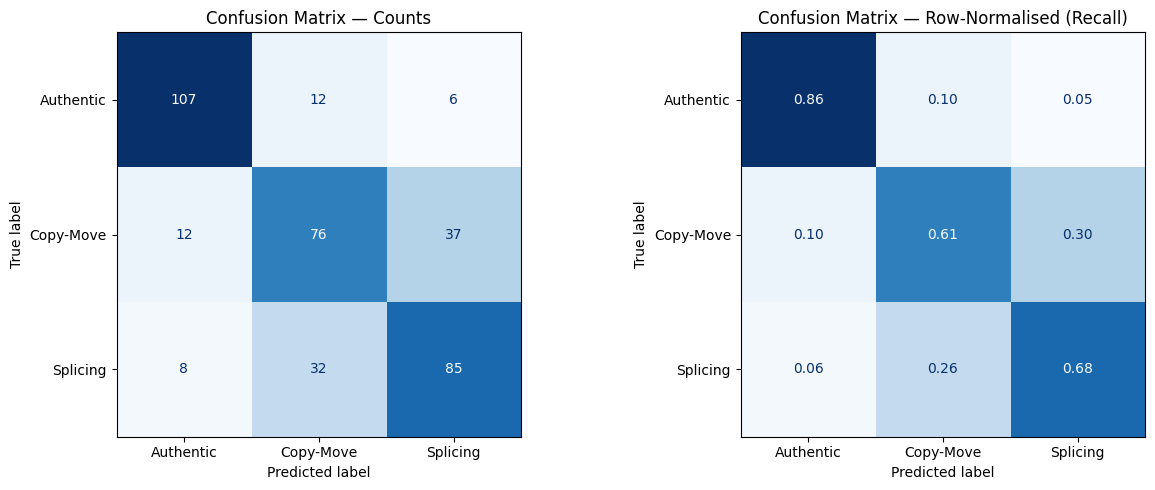

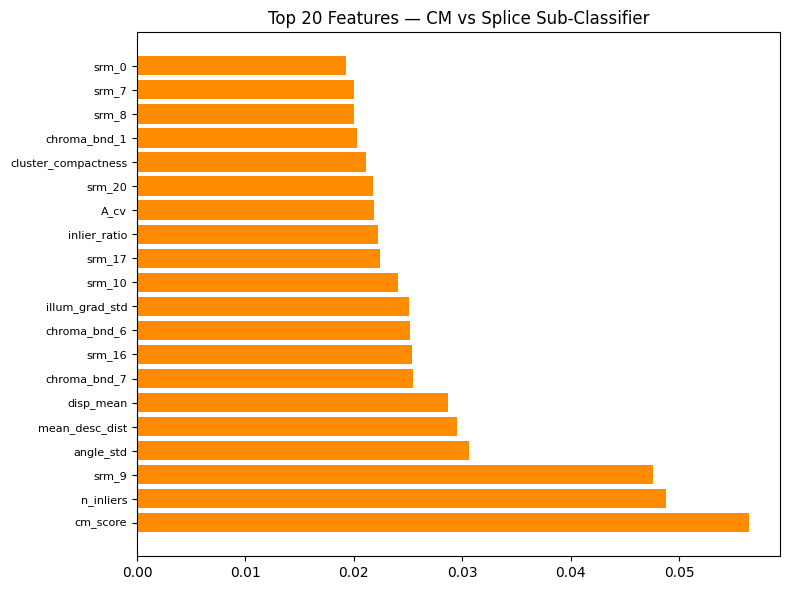

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

# ── Index slices used by the two-stage classifier ──────────────────────────
# Features most relevant to CM-vs-Splice distinction (excludes DCT Markov bulk)
# selfsim: indices 307-313, chroma_bnd: 314-324, AKAZE: 0-9, SRM: 206-227
CM_SP_FEAT_IDX = (
    list(range(0, 10))          # AKAZE (incl. hard flag + consistency)
    + list(range(206, 228))     # SRM noise (chroma inconsistency)
    + list(range(299, 304))     # Illumination
    + list(range(304, 311))     # Spatial self-similarity
    + list(range(311, 322))     # Chroma boundary
)


def train_and_evaluate(X, y):
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, stratify=y, random_state=42
    )

    # ── Stage 1: full 3-class GBM ────────────────────────────────────────────
    scaler1 = StandardScaler()
    Xtr1    = scaler1.fit_transform(X_train)
    Xte1    = scaler1.transform(X_test)

    clf1 = GradientBoostingClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.07,
        subsample=0.8, min_samples_leaf=3, max_features='sqrt', random_state=42,
    )
    clf1.fit(Xtr1, y_train)

    # ── Stage 2: dedicated CM-vs-Splice sub-classifier ───────────────────────
    # Trained only on tampered images, using the discriminating feature subset
    tampered_mask_tr = y_train != 0
    X_cm_sp_tr = X_train[tampered_mask_tr][:, CM_SP_FEAT_IDX]
    y_cm_sp_tr = y_train[tampered_mask_tr]   # still 1 or 2

    scaler2 = StandardScaler()
    Xtr2    = scaler2.fit_transform(X_cm_sp_tr)

    clf2 = GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.08,
        subsample=0.8, min_samples_leaf=3, max_features='sqrt', random_state=42,
    )
    clf2.fit(Xtr2, y_cm_sp_tr)

    # ── Calibrate AKAZE hard-flag threshold on training set ──────────────────
    # Find cm_score threshold such that precision >= 0.90 on training data
    cm_scores_tr = X_train[:, 0]   # index 0 = cm_score
    hard_flags_tr = X_train[:, CM_HARD_FLAG_IDX]
    flagged_tr    = hard_flags_tr > 0.5
    if flagged_tr.sum() > 0:
        flag_precision = float((y_train[flagged_tr] == 1).mean())
        print(f"  AKAZE hard-flag: {flagged_tr.sum()} triggered, "
              f"precision={flag_precision:.2%} on training set")
    else:
        print("  AKAZE hard-flag: 0 triggered on training set — soft rule only")

    # ── Combined prediction function ─────────────────────────────────────────
    def predict_combined(X_raw):
        X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)
        Xs1   = scaler1.transform(X_raw)
        preds = clf1.predict(Xs1).copy()

        # For images predicted as tampered (1 or 2), override with stage-2
        tampered_mask = preds != 0
        if tampered_mask.sum() > 0:
            X_sub = X_raw[tampered_mask][:, CM_SP_FEAT_IDX]
            Xs2   = scaler2.transform(X_sub)
            preds[tampered_mask] = clf2.predict(Xs2)

        # Hard AKAZE override: if cm_hard_flag=1 AND stage-1 says tampered,
        # force copy-move prediction (high precision rule)
        hard_flag   = X_raw[:, CM_HARD_FLAG_IDX] > 0.5
        is_tampered = preds != 0
        override    = hard_flag & is_tampered
        if override.sum() > 0:
            preds[override] = 1   # force copy-move

        return preds

    preds  = predict_combined(X_test)
    probas = clf1.predict_proba(Xte1)   # for confidence histograms

    print("\n=== Classification Report ===")
    print(classification_report(y_test, preds,
                                 target_names=['Authentic', 'Copy-Move', 'Splicing']))
    print('Balanced Accuracy:', f"{balanced_accuracy_score(y_test, preds):.3f}")

    # 5-fold CV (stage-1 only for speed, gives conservative estimate)
    cv_sk  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipe   = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=400, max_depth=5, learning_rate=0.07,
            subsample=0.8, min_samples_leaf=3, max_features='sqrt', random_state=42))
    ])
    scores = cross_val_score(pipe, X, y, cv=cv_sk, scoring='balanced_accuracy', n_jobs=1)
    print(f'\nCV Balanced Accuracy (stage-1): {scores.mean():.3f} ± {scores.std():.3f}')
    print('Per-fold:', np.round(scores, 3))

    # ── Confusion matrices (counts + normalised) ─────────────────────────────
    labels     = ['Authentic', 'Copy-Move', 'Splicing']
    cm_counts  = confusion_matrix(y_test, preds)
    cm_norm    = confusion_matrix(y_test, preds, normalize='true')

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ConfusionMatrixDisplay(cm_counts, display_labels=labels).plot(
        ax=axes[0], cmap='Blues', colorbar=False
    )
    axes[0].set_title('Confusion Matrix — Counts', fontsize=12)

    ConfusionMatrixDisplay(cm_norm, display_labels=labels).plot(
        ax=axes[1], cmap='Blues', colorbar=False
    )
    axes[1].set_title('Confusion Matrix — Row-Normalised (Recall)', fontsize=12)
    for t in axes[1].texts:
        try:
            t.set_text(f"{float(t.get_text()):.2f}")
        except ValueError:
            pass

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Feature importance (top 25, stage-2 CM-vs-Splice sub-classifier) ─────
    imps2  = clf2.feature_importances_
    names2 = [FEATURE_NAMES[i] for i in CM_SP_FEAT_IDX]
    order2 = np.argsort(imps2)[::-1][:20]
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    ax2.barh(range(len(order2)), imps2[order2][::-1], color='darkorange')
    ax2.set_yticks(range(len(order2)))
    ax2.set_yticklabels([names2[i] for i in order2[::-1]], fontsize=8)
    ax2.set_title('Top 20 Features — CM vs Splice Sub-Classifier')
    ax2.invert_yaxis()
    plt.tight_layout()
    plt.show()

    return clf1, clf2, scaler1, scaler2, predict_combined


clf1, clf2, scaler1, scaler2, predict_fn = train_and_evaluate(X, y)

         EVALUATION SUMMARY
  Total test samples   : 375
  Overall Accuracy     : 71.5%
  Balanced Accuracy    : 71.5%
----------------------------------------------------
  Class            Prec    Rec     F1     N
----------------------------------------------------
  Authentic       84.3%  85.6%  84.9%   125
  Copy-Move       63.3%  60.8%  62.0%   125
  Splicing        66.4%  68.0%  67.2%   125
----------------------------------------------------
  CM vs Splice acc     : 64.4%  ← key metric


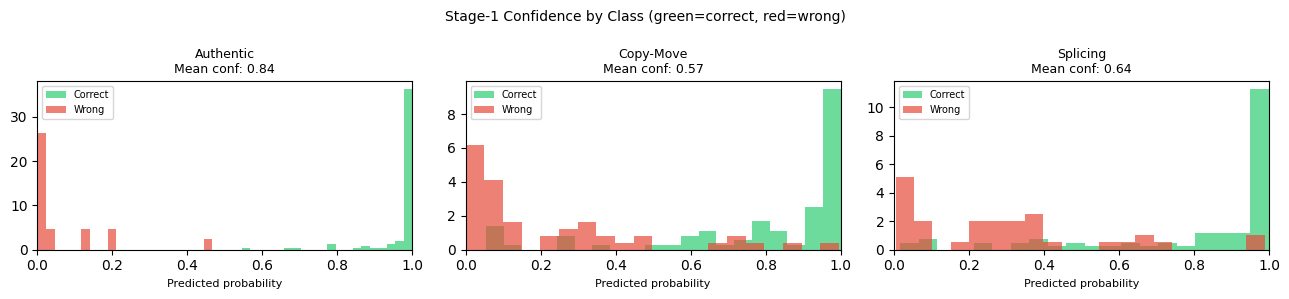

In [28]:
def print_full_summary(predict_fn, clf1, scaler1, X, y):
    X_clean = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    _, X_test_f, _, y_test_f = train_test_split(
        X_clean, y, test_size=0.25, stratify=y, random_state=42
    )
    preds    = predict_fn(X_test_f)
    probas   = clf1.predict_proba(scaler1.transform(X_test_f))

    overall_acc = accuracy_score(y_test_f, preds)
    bal_acc     = balanced_accuracy_score(y_test_f, preds)
    report      = classification_report(
        y_test_f, preds,
        target_names=['Authentic', 'Copy-Move', 'Splicing'],
        output_dict=True
    )

    print("=" * 52)
    print("         EVALUATION SUMMARY")
    print("=" * 52)
    print(f"  Total test samples   : {len(y_test_f)}")
    print(f"  Overall Accuracy     : {overall_acc:.1%}")
    print(f"  Balanced Accuracy    : {bal_acc:.1%}")
    print("-" * 52)
    print(f"  {'Class':<14} {'Prec':>6} {'Rec':>6} {'F1':>6} {'N':>5}")
    print("-" * 52)
    for name in ['Authentic', 'Copy-Move', 'Splicing']:
        r = report[name]
        print(f"  {name:<14} {r['precision']:>6.1%} {r['recall']:>6.1%} "
              f"{r['f1-score']:>6.1%} {int(r['support']):>5}")
    print("-" * 52)

    mask_cms = (y_test_f == 1) | (y_test_f == 2)
    if mask_cms.sum() > 0:
        cms_acc = accuracy_score(y_test_f[mask_cms], preds[mask_cms])
        print(f"  CM vs Splice acc     : {cms_acc:.1%}  ← key metric")
    print("=" * 52)

    # Confidence histograms (from stage-1 probas, for visualisation only)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3))
    for i, name in enumerate(['Authentic', 'Copy-Move', 'Splicing']):
        mask = y_test_f == i
        if mask.sum() == 0:
            continue
        conf         = probas[mask, i]
        correct_mask = preds[mask] == i
        axes[i].hist(conf[correct_mask],  bins=20, alpha=0.7, color='#2ecc71',
                     label='Correct', density=True)
        axes[i].hist(conf[~correct_mask], bins=20, alpha=0.7, color='#e74c3c',
                     label='Wrong',   density=True)
        axes[i].set_title(f'{name}\nMean conf: {conf.mean():.2f}', fontsize=9)
        axes[i].set_xlabel('Predicted probability', fontsize=8)
        axes[i].legend(fontsize=7)
        axes[i].set_xlim(0, 1)

    plt.suptitle('Stage-1 Confidence by Class (green=correct, red=wrong)', fontsize=10)
    plt.tight_layout()
    plt.show()


print_full_summary(predict_fn, clf1, scaler1, X, y)